<a href="https://colab.research.google.com/github/bohanlaii/data_class/blob/main/final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [16]:
from google.colab import files
uploaded = files.upload()

Saving global_electricity_production_data.csv to global_electricity_production_data.csv


In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [18]:
file_name = 'global_electricity_production_data.csv'


In [20]:
try:
    df = pd.read_csv(file_name)
    print("✅ File loaded successfully!")
except FileNotFoundError:
    print(f"❌ Error: Could not find '{file_name}'. Please upload it to Google Colab.")

✅ File loaded successfully!


In [21]:
df['date_dt'] = pd.to_datetime(df['date'], format='mixed', errors='coerce')

In [22]:
net_prod = df[df['parameter'] == 'Net Electricity Production'].copy()

In [23]:
sns.set_theme(style="whitegrid")
fig = plt.figure(figsize=(12, 10))

<Figure size 1200x1000 with 0 Axes>

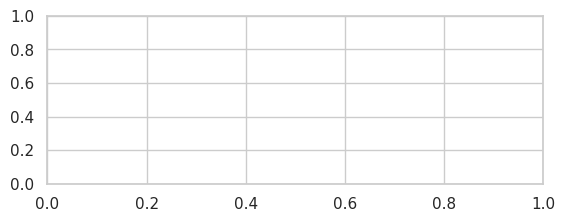

In [24]:
ax1 = plt.subplot(2, 1, 1)
renewable_techs = ['Wind', 'Solar', 'Hydro']
df_ren = net_prod[net_prod['product'].isin(renewable_techs)]
yearly_ren = df_ren.groupby([df_ren['date_dt'].dt.year, 'product'])['value'].sum().reset_index()

In [25]:
sns.lineplot(
    data=yearly_ren,
    x='date_dt',
    y='value',
    hue='product',
    marker='o',
    linewidth=2.5,
    ax=ax1,
    palette=['#3498db', '#f1c40f', '#2ecc71']
)

<Axes: xlabel='date_dt', ylabel='value'>

In [26]:
ax1.set_title('Figure 1: Global Annual Growth of Renewable Energy Sources (2010–2023)', fontsize=13, fontweight='bold', pad=12)
ax1.set_xlabel('Year', fontsize=11)
ax1.set_ylabel('Total Electricity Production (GWh)', fontsize=11)
ax1.legend(title='Energy Source', loc='upper left')

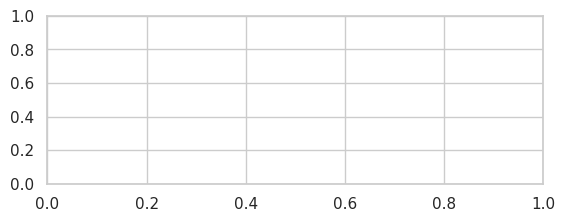

In [27]:
ax2 = plt.subplot(2, 1, 2)
energy_sources = ['Coal, Peat and Manufactured Gases', 'Natural Gas', 'Hydro', 'Wind', 'Nuclear', 'Solar']
df_2023 = net_prod[(net_prod['date_dt'].dt.year == 2023) & (net_prod['product'].isin(energy_sources))]
product_2023 = df_2023.groupby('product')['value'].sum().reset_index().sort_values(by='value', ascending=False)

In [28]:
palette_colors = ['#e74c3c' if x in ['Coal, Peat and Manufactured Gases', 'Natural Gas'] else '#2ecc71' for x in product_2023['product']]

sns.barplot(
    data=product_2023,
    x='value',
    y='product',
    palette=palette_colors,
    ax=ax2
)
ax2.set_title('Figure 2: Global Electricity Production Breakdown by Energy Source (2023 Snapshot)', fontsize=13, fontweight='bold', pad=12)
ax2.set_xlabel('Total Generation (GWh)', fontsize=11)
ax2.set_ylabel('Energy Source', fontsize=11)

plt.tight_layout()
plt.show()
print("✅ High-quality EDA figures generated successfully!")

/tmp/ipykernel_2498/4198870715.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


<Figure size 640x480 with 0 Axes>

✅ High-quality EDA figures generated successfully!
